<a href="https://colab.research.google.com/github/YouriKaufmann/CVaR-Tool/blob/main/EN_Climate_Stress_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Read the "Static Company Data" file
chemin_excel = '/content/drive/MyDrive/Stress Test Climatique/Outil/Données Statiques Entreprises - CVaR.xlsx'
df_companies = pd.read_excel(chemin_excel)

# 3. Verify the import
print(df_companies.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
        Name  Ticker  Scope_1_2  Scope_3  %_of_Green Revenue  Pass_Through  \
0     Kering  KER.PA     162149  2116428                   0          0.75   
1     Hermès  RMS.PA      52257   735000                   0          0.90   
2       LVMH   MC.PA     535700  7522620                   0          0.80   
3   Burberry  BRBY.L      18975   409994                   0          0.65   
4  Richemont  CFR.SW      75662  1633300                   0          0.90   

     WACC  
0  0.0713  
1  0.0713  
2  0.0713  
3  0.0713  
4  0.0713  


In [ ]:
import numpy as np
import yfinance as yf
import pandas as pd

# 1. Scenario Parameters
CARBON_PRICE_BASE = 0
CARBON_PRICE_TARGET = 100
GREEN_MARKET_GROWTH = 0
HORIZON = 10

# 2. Calculation function (Returns 2 outputs: the sector AND the score)
def calculate_cvar_and_sector(row):
    try:
        # Retrieve Yahoo Finance data
        tk = yf.Ticker(row['Ticker'])
        info = tk.info

        extracted_sector = info.get('sector', 'Inconnu')
        ebitda = info.get('ebitda', 0)
        mkt_cap = info.get('marketCap', 0)

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([extracted_sector, 0])

        # A. Risk Calculation
        total_emissions = row['Scope_1_2'] + row['Scope_3']
        gross_carbon_cost = total_emissions * (CARBON_PRICE_TARGET - CARBON_PRICE_BASE)
        transferred_amount = gross_carbon_cost * row['Pass_Through']
        annual_net_cost = gross_carbon_cost - transferred_amount

        # B. Opportunity Calculation
        annual_upside = ebitda * row['%_of_Green Revenue'] * GREEN_MARKET_GROWTH

        # C. Annual Net Cash FLow
        delta_cf = annual_upside - annual_net_cost

        # D. Discounting
        wacc = row['WACC']
        pv_impact = sum([delta_cf / ((1 + wacc)**t) for t in range(1, HORIZON + 1)])

        # E. Score Market Cap Final
        cvar_score_mktcap = round((pv_impact / mkt_cap) * 100, 2)

        # F. Score EBITDA Final
        cvar_score_ebitda = round((pv_impact / ebitda) * 100, 2)

        return pd.Series([extracted_sector, cvar_score_mktcap, cvar_score_ebitda])

    except Exception as e:
        return pd.Series(['Erreur', None, None])

# 3. Execution
print("Computing scores (fetching Yahoo Finance data)...")
df_companies[['Sector', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']] = df_companies.apply(calculate_cvar_and_sector, axis=1)

# 4. Display rankings
results = df_companies[['Name', 'Ticker', 'Sector', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA']].sort_values(by='CVaR_Score_Mktcap', ascending=False)
print(results)

Computing scores (fetching Yahoo Finance data)...
        Name   Ticker             Sector  CVaR_Score_Mktcap  CVaR_Score_EBITDA
1     Hermès   RMS.PA  Consumer Cyclical              -0.03              -0.78
4  Richemont   CFR.SW  Consumer Cyclical              -0.14              -2.23
5    Moncler  MONC.MI  Consumer Cyclical              -0.25              -3.49
2       LVMH    MC.PA  Consumer Cyclical              -0.51              -5.47
0     Kering   KER.PA  Consumer Cyclical              -1.43             -15.64
3   Burberry   BRBY.L  Consumer Cyclical              -2.49             -51.89


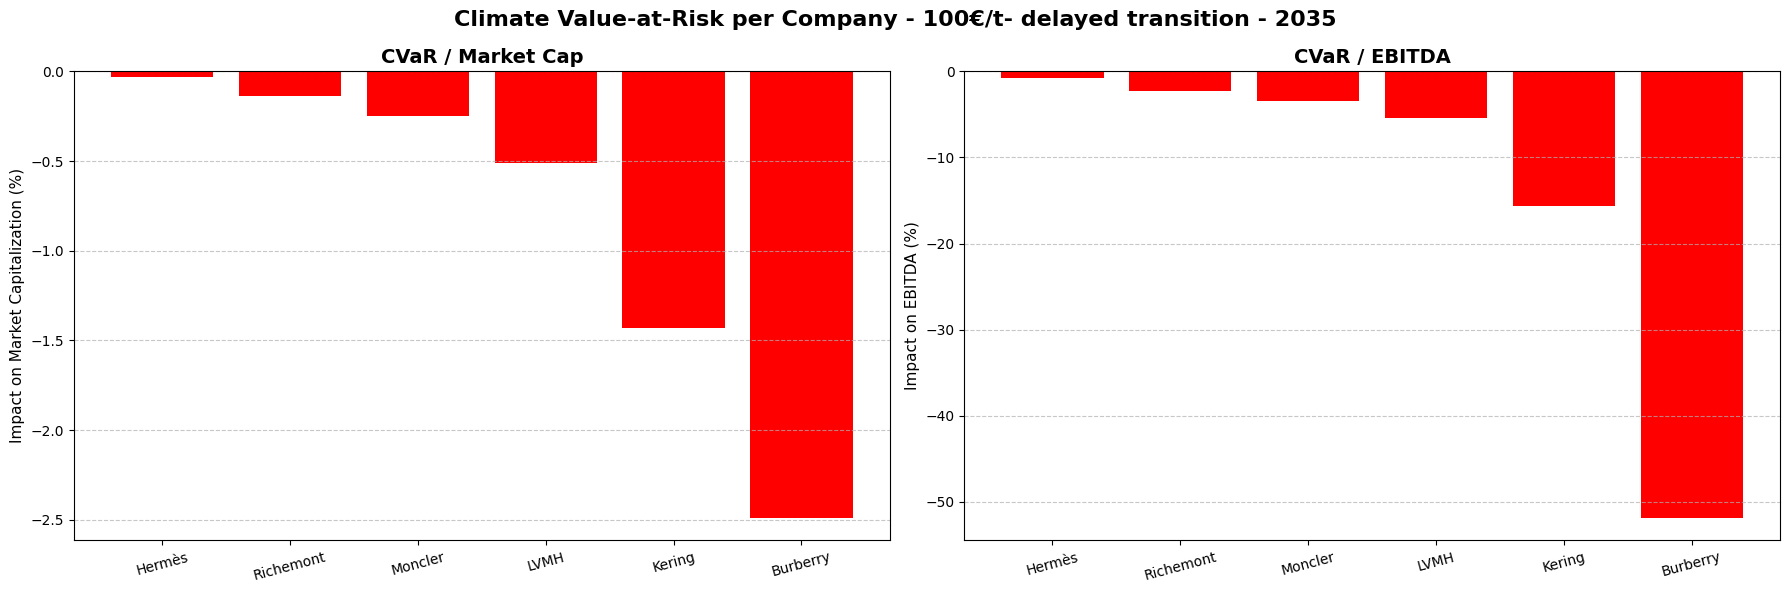

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

couleurs1 = ['green' if score > 0 else 'red' for score in results['CVaR_Score_Mktcap']]
ax1.bar(results['Name'], results['CVaR_Score_Mktcap'], color=couleurs1)
ax1.set_title('CVaR / Market Cap', fontsize=14, fontweight='bold')
ax1.set_ylabel('Impact on Market Capitalization (%)', fontsize=11)
ax1.axhline(0, color='black', linewidth=1.2)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='x', rotation=15)

couleurs2 = ['green' if score > 0 else 'red' for score in results['CVaR_Score_EBITDA']]
ax2.bar(results['Name'], results['CVaR_Score_EBITDA'], color=couleurs2)
ax2.set_title('CVaR / EBITDA', fontsize=14, fontweight='bold')
ax2.set_ylabel('Impact on EBITDA (%)', fontsize=11)
ax2.axhline(0, color='black', linewidth=1.2)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='x', rotation=15)

plt.suptitle('Climate Value-at-Risk per Company - 100€/t- delayed transition - 2035', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def calculate_cvar_audit_total(row):
    try:
        tk = yf.Ticker(row['Ticker'])
        info = tk.info

        sector = info.get('sector', 'Inconnu')
        ebitda = info.get('ebitda', 0)
        mkt_cap = info.get('marketCap', 0)

        if ebitda == 0 or mkt_cap == 0:
            return pd.Series([sector, ebitda, mkt_cap, 0, 0, 0, 0, 0, None, None, None, None])

        # A. Risk Calculation
        emissions = row['Scope_1_2'] + row['Scope_3']
        gross_carbon_cost = emissions * (CARBON_PRICE_TARGET - CARBON_PRICE_BASE)
        net_carbon_cost = gross_carbon_cost * (1 - row['Pass_Through'])

        # B. Opportunity Calculation
        annual_upside = ebitda * row['%_of_Green Revenue'] * GREEN_MARKET_GROWTH

        # C. Net Cash Flow and Discounting
        delta_cf = annual_upside - net_carbon_cost
        wacc = row['WACC']
        vp_impact = sum([delta_cf / ((1 + wacc)**t) for t in range(1, HORIZON + 1)])

        # D. Final Scores
        cvar_score_mktcap = (vp_impact / mkt_cap) * 100
        cvar_score_ebitda = (vp_impact / ebitda) * 100

        # E. Complementary Indicators
        revenues = info.get('totalRevenue', 0)
        carbon_intensity = round((emissions / (revenues / 1e6)), 2) if revenues > 0 else None
        debt_ebitda_ratio = round(info.get('totalDebt', 0) / ebitda, 2) if ebitda > 0 else None

        return pd.Series([sector, ebitda, mkt_cap, gross_carbon_cost, net_carbon_cost, annual_upside, delta_cf, vp_impact, round(cvar_score_mktcap, 2), round(cvar_score_ebitda, 2), carbon_intensity, debt_ebitda_ratio])
    except Exception as e:
        return pd.Series(['Erreur', 0, 0, 0, 0, 0, 0, 0, None, None, None, None])

# Apply to dataframe
cols_audit = ['Sector', 'EBITDA', 'Market_Cap', 'gross_carbon_cost', 'net_carbon_cost', 'Green_Upside', 'Delta_CF', 'Cumulative_Impact', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA', 'carbon_intensity', 'debt_ebitda_ratio']
df_companies[cols_audit] = df_companies.apply(calculate_cvar_audit_total, axis=1)

In [ ]:
def generate_expert_audit_report(df):
    # 1.Select the logical column order for readability

    ordre_lecture = [
    'Name', 'Ticker', 'Sector', 'Scope_1_2', 'Scope_3',
    'carbon_intensity', 'debt_ebitda_ratio',
    'EBITDA', 'Market_Cap', 'gross_carbon_cost', 'Pass_Through',
    'net_carbon_cost', '%_of_Green Revenue', 'Green_Upside',
    'Delta_CF', 'WACC', 'Cumulative_Impact', 'CVaR_Score_Mktcap', 'CVaR_Score_EBITDA'
]

    # 2. Keep only columns that actually exist in the dataframe
    cols_finales = [c for c in ordre_lecture if c in df.columns]

    # 3. Sort from best to worst performers
    df_trie = df[cols_finales].sort_values(by='CVaR_Score_Mktcap', ascending=False)

    # 4. Apply styling
    return df_trie.style\
        .set_caption("Detailled Data : from CO2e to CVaR scores")\
        .format({
            'Scope_1_2': '{:,.0f} t',
            'Scope_3': '{:,.0f} t',
            'EBITDA': lambda x: f"{x/1e6:,.0f} M€",
            'Market_Cap': lambda x: f"{x/1e9:,.1f} Md€",
            'gross_carbon_cost': lambda x: f"-{x/1e6:,.1f} M€",
            'net_carbon_cost': lambda x: f"-{x/1e6:,.1f} M€",
            'Green_Upside': lambda x: f"+{x/1e6:,.1f} M€",
            'Delta_CF': lambda x: f"{x/1e6:,.1f} M€",
            'Cumulative_Impact': lambda x: f"{x/1e6:,.1f} M€",
            'Pass_Through': '{:.0%}',
            '%_of_Green Revenue': '{:.0%}',
            'WACC': '{:.1%}',
            'CVaR_Score_Mktcap': '{:+.2f}%',
            'CVaR_Score_EBITDA': '{:+.2f}%',
            'carbon_intensity': '{:,.1f} tCO2e/M€CA',
            'debt_ebitda_ratio': '{:.1f}x',
        })\
        .map(lambda v: f'color: {"#d65f5f" if v < 0 else "#5fba7d"}; font-weight: bold', subset=['CVaR_Score_Mktcap', 'CVaR_Score_EBITDA'])\
        .set_properties(**{'text-align': 'right', 'font-size': '12px'})\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white'), ('text-align', 'center')]},
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('padding', '10px')]}
        ])



# --- Display ---
print("✅ Generating final audit table...")
generate_expert_audit_report(df_companies)

✅ Generating final audit table...


,Name,Ticker,Sector,Scope_1_2,Scope_3,carbon_intensity,debt_ebitda_ratio,EBITDA,Market_Cap,gross_carbon_cost,Pass_Through,net_carbon_cost,%_of_Green Revenue,Green_Upside,Delta_CF,WACC,Cumulative_Impact,CVaR_Score_Mktcap,CVaR_Score_EBITDA
1,Hermès,RMS.PA,Consumer Cyclical,"52,257 t","735,000 t",49.2 tCO2e/M€CA,0.3x,"7,041 M€",165.4 Md€,-78.7 M€,90%,-7.9 M€,0%,+0.0 M€,-7.9 M€,7.1%,-55.0 M€,-0.03%,-0.78%
4,Richemont,CFR.SW,Consumer Cyclical,"75,662 t","1,633,300 t",77.9 tCO2e/M€CA,2.8x,"5,348 M€",85.6 Md€,-170.9 M€,90%,-17.1 M€,0%,+0.0 M€,-17.1 M€,7.1%,-119.3 M€,-0.14%,-2.23%
5,Moncler,MONC.MI,Consumer Cyclical,"20,140 t","227,986 t",79.2 tCO2e/M€CA,1.1x,994 M€,13.9 Md€,-24.8 M€,80%,-5.0 M€,0%,+0.0 M€,-5.0 M€,7.1%,-34.6 M€,-0.25%,-3.49%
2,LVMH,MC.PA,Consumer Cyclical,"535,700 t","7,522,620 t",99.7 tCO2e/M€CA,1.8x,"20,587 M€",220.3 Md€,-805.8 M€,80%,-161.2 M€,0%,+0.0 M€,-161.2 M€,7.1%,"-1,125.2 M€",-0.51%,-5.47%
0,Kering,KER.PA,Consumer Cyclical,"162,149 t","2,116,428 t",155.3 tCO2e/M€CA,7.3x,"2,543 M€",27.8 Md€,-227.9 M€,75%,-57.0 M€,0%,+0.0 M€,-57.0 M€,7.1%,-397.7 M€,-1.43%,-15.64%
3,Burberry,BRBY.L,Consumer Cyclical,"18,975 t","409,994 t",178.2 tCO2e/M€CA,7.7x,202 M€,4.2 Md€,-42.9 M€,65%,-15.0 M€,0%,+0.0 M€,-15.0 M€,7.1%,-104.8 M€,-2.49%,-51.89%
